Checking folder: plant data set\class1
Checking folder: plant data set\class2
Images shape: (10, 64, 64, 3)
Labels shape: (10,)


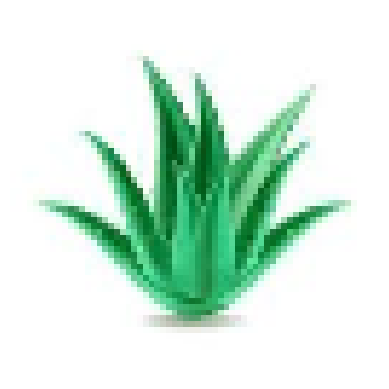

In [24]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

data_path = "plant data set"
categories = ["class1", "class2"]

data = []
labels = []
img_size = 64

for category in categories:

    folder_path = os.path.join(data_path, category)
    label = categories.index(category)

    print("Checking folder:", folder_path)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        # Read image
        img = cv2.imread(img_path)

        # Skip files that are not images
        if img is None:
            print("Skipped:", img_path)
            continue

        # Resize
        img = cv2.resize(img, (img_size, img_size))

        data.append(img)
        labels.append(label)

X = np.array(data) / 255.0
y = np.array(labels)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

plt.imshow(X[0])
plt.axis("off")
plt.show()

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Ashwani\OneDrive\Desktop\3rd SEM\Machine learning\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,968,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969,153 (7.51 MB)

 Trainable params: 1,969,153 (7.51 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.7071 - val_accuracy: 0.5000 - val_loss: 1.3491
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5000 - loss: 0.9703 - val_accuracy: 0.5000 - val_loss: 1.6168
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5000 - loss: 1.3985 - val_accuracy: 0.5000 - val_loss: 0.9382
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5000 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.8381
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7500 - loss: 0.4387 - val_accuracy: 0.5000 - val_loss: 1.2523
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5000 - loss: 0.6063 - val_accuracy: 0.5000 - val_loss: 1.1767
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6250 - loss: 0.4741 - val_accuracy: 0.5000 - val_loss: 0.7759
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8750 - loss: 0.2290 - val_accuracy: 1.0000 - val_loss: 0.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8, 64, 64, 3)
Testing data: (2, 64, 64, 3)


In [28]:
test_img = cv2.imread("test.png")
test_img = cv2.resize(test_img, (64,64))
test_img = test_img / 255.0
test_img = np.reshape(test_img, (1,64,64,3))

prediction = model.predict(test_img)

if prediction[0][0] > 0.5:
    print("Predicted: class2")
else:
    print("Predicted: class1")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Predicted: class1
